# Non-FFT DSP Chain — Step-by-Step Walkthrough

End-to-end Python reference for the streaming non-FFT frontend path.
Corresponds to `planning/DSP Flow.md` and `planning/Non-FFT LoRa Frontend Proposal.md`.

**Chain under test:**

```
Modulate → Channel → Decimator → DC Removal → (Frontend Buffer 8-bit → SC Preamble Detector)
        → Training Accumulator → Weight Generation → [Noise Floor Estimation] → MRC Combiner → ΣΔ Re-modulator → Demodulate
```

Stage mapping to `planning/DSP Flow.md`:

| Stage | Block |
|---|---|
| 2 | ΣΔ Decimator (modelled as full-precision float) |
| 3 | DC Removal — IIR running mean, DC_ALPHA_SHIFT=8 |
| 4 | Frontend Buffer → 8-bit saturated samples for SC |
| 5 | SC Preamble Detector → `sc_lock`, `timing_ref` |
| 6 | Training Accumulator → `Z_j = Σ rx_j[n]·conj(rx_ref[n])` (cross-correlation) |
| 7 | Weight Generation — SHIFT→CALIBRATE→COMPUTE→SCALE, modes: MRC/EGC/SC/Bypass |
| 7b | Noise Floor Estimation — firmware EMA of idle-period `Σ\|x\|²/M` → per-branch `σ²_j` |
| 8 | MRC Combiner — `y[n] = w^H · x[n]`; NW-MRC uses `σ²_j` for per-branch weighting |
| 9 | ΣΔ Re-modulator — 3rd order, int16 → 1-bit |

**Key properties of the non-FFT path:**
- No FFT engine, no capture SRAM, no RCTSL CFO estimation
- CFO cancels exactly in the cross-correlation: `Z_j = Σ rx_j·conj(rx_ref)` eliminates Dirichlet nulling at all CFO values
- Weight Generation includes int64→int32 shift normalisation (`shift_normalise`) before the COMPUTE step
- Full-precision samples (not 8-bit SRAM) feed the training accumulator and combiner
- Noise floor estimation requires no new RTL: uses existing Energy Measurement outputs during IDLE state

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('../..').resolve()))

import matplotlib
matplotlib.use('Agg')
import numpy as np
import matplotlib.pyplot as plt

from sim.models.lora import modulate, demodulate
from sim.models.channel import rayleigh_coefficients, apply_channel
from sim.models.decimator import SigmaDeltaDecimator
from sim.models.dc_removal import DCRemoval
from sim.models.sync import SchmidlCoxDetector
from sim.models.stages import energy_detector
from sim.models.training_accumulator import (
    training_accumulate, compute_weights, chirp_reference, cfo_diagnostic
)
from sim.models.weight_generation import WeightGenerator, shift_normalise
from sim.models.receiver import nonfft_combine
from sim.models.converter import SigmaDeltaRemodulator
from sim.models.fixed import quantize, quantize_q1_15

rng = np.random.default_rng(42)
np.random.seed(42)   # seed global state used by apply_channel / rayleigh_coefficients
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True})

import io as _io
from IPython.display import Image as _Image, display as _ipy_display

def show(fig=None):
    """Render figure to PNG and display inline; works with Agg backend."""
    if fig is None:
        fig = plt.gcf()
    buf = _io.BytesIO()
    fig.savefig(buf, format='png', bbox_inches='tight', dpi=110)
    buf.seek(0)
    _ipy_display(_Image(data=buf.read()))
    plt.close(fig)

In [2]:
# ── System constants ─────────────────────────────────────────────────────────
SF   = 6          # Spreading factor (SF6 = primary operating point)
M    = 2 ** SF    # Samples per symbol = 64
BW   = 125e3      # Bandwidth (Hz)
NR   = 4          # Receive antennas
N_PREAMBLE = 8    # LoRa preamble upchirp count
SC_HITS_REQ = 2   # SC consecutive hits to declare lock

# Training accumulator window
# sc_lock fires after SC_HITS_REQ hits, approximately (SC_HITS_REQ+1)·M samples in
# => ~5 of 8 preamble symbols accumulated; ~2 dB SNR penalty vs ideal
EXPECTED_N_ACC = (N_PREAMBLE - SC_HITS_REQ - 1) * M   # ≈ 320 samples at SF6

# SNR for the single-packet walkthrough cells (high enough that SC reliably locks)
# The BER sweep covers the full -15 to +5 dB range independently.
SNR_DB = 0.0
N0 = 10 ** (-SNR_DB / 10)

print(f'SF={SF}, M={M}, NR={NR}, SNR={SNR_DB} dB, N0={N0:.4f}')
print(f'Expected n_acc ≈ {EXPECTED_N_ACC} samples ({EXPECTED_N_ACC/M:.1f} symbols)')

SF=6, M=64, NR=4, SNR=0.0 dB, N0=1.0000
Expected n_acc ≈ 320 samples (5.0 symbols)


## Stage 1 — Modulation

Generate a LoRa preamble (8 upchirps) followed by one payload symbol.

In [3]:
upchirp   = np.exp(1j * np.pi * np.arange(M) ** 2 / M)
preamble  = np.tile(upchirp, N_PREAMBLE)      # 8 × M samples

b_tx      = int(rng.integers(0, M))
payload   = modulate(b_tx, M)                  # 1 symbol = M samples

tx_frame  = np.concatenate([preamble, payload])  # (N_PREAMBLE+1)·M samples

print(f'Transmitted symbol: b_tx = {b_tx}')
print(f'Frame length: {len(tx_frame)} samples ({len(tx_frame)/M:.0f} symbols)')

Transmitted symbol: b_tx = 5
Frame length: 576 samples (9 symbols)


## Stage 2 — Channel

Independent Rayleigh fading coefficients per antenna.

In [4]:
# Add noise-free guard before the preamble so SC has context to slide over
GUARD_SAMPLES = 2 * M
guard = np.zeros(GUARD_SAMPLES, dtype=complex)
frame_with_guard = np.concatenate([guard, tx_frame])

h_true = rayleigh_coefficients(NR, pll_phase_random=True)
rx = np.stack([apply_channel(frame_with_guard, h_true[j], N0) for j in range(NR)])

print('True channel coefficients h_j:')
for j in range(NR):
    print(f'  h[{j}] = {h_true[j]:.4f}  |h| = {abs(h_true[j]):.4f}  φ = {np.degrees(np.angle(h_true[j])):+.1f}°')

True channel coefficients h_j:
  h[0] = -0.3697+0.1189j  |h| = 0.3883  φ = +162.2°
  h[1] = 0.1271+0.1442j  |h| = 0.1923  φ = +48.6°
  h[2] = -1.1969-0.1550j  |h| = 1.2069  φ = -172.6°
  h[3] = 0.2751-1.1741j  |h| = 1.2059  φ = -76.8°


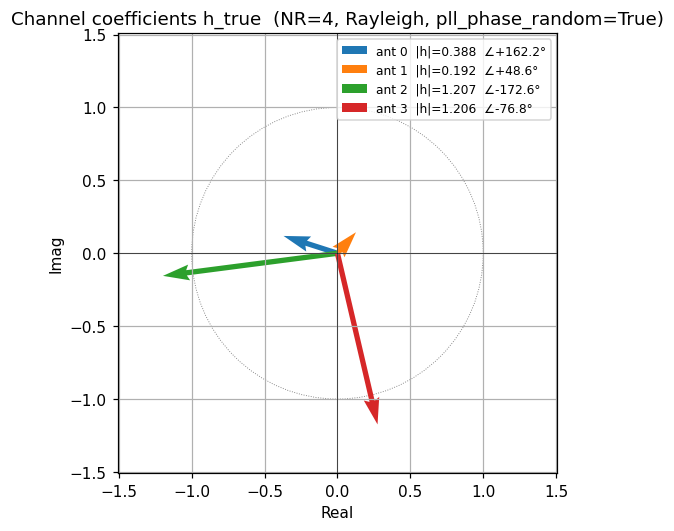

In [5]:
# IQ phasor plot — per-antenna channel coefficients h_true.
# Each antenna has an independent Rayleigh fading coefficient; the spread of
# magnitudes and phases determines the MRC combining gain.
fig, ax = plt.subplots(figsize=(5, 5))

lim = max(np.abs(h_true).max() * 1.25, 0.5)
ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
ax.add_patch(plt.Circle((0, 0), 1, color='grey', fill=False, lw=0.6, linestyle=':'))
ax.axhline(0, color='k', lw=0.4); ax.axvline(0, color='k', lw=0.4)

for j in range(NR):
    h = h_true[j]
    ax.quiver(0, 0, h.real, h.imag,
              angles='xy', scale_units='xy', scale=1,
              color=f'C{j}', width=0.012,
              label=f'ant {j}  |h|={abs(h):.3f}  ∠{np.degrees(np.angle(h)):+.1f}°')

ax.set_aspect('equal')
ax.legend(fontsize=8)
ax.set_xlabel('Real'); ax.set_ylabel('Imag')
ax.set_title(f'Channel coefficients h_true  (NR={NR}, Rayleigh, pll_phase_random=True)')
plt.tight_layout()
show()

## Stage 3 — DC Removal

Per-branch IIR running-mean subtraction removes residual DC bias from the
SX1257 direct-conversion mixer before any phase-sensitive processing.

Hardware equation: `dc_est[j] += (raw[j][n] - dc_est[j]) >> DC_ALPHA_SHIFT`

Time constant τ = 2^DC_ALPHA_SHIFT = 256 samples at the default setting.
Must run on **full-precision** decimator output (not 8-bit saturated SRAM samples).

The 8-bit saturated copy (Frontend Buffer path) is derived **after** DC removal
and is used only by the SC Preamble Detector.

In [6]:
dcr = DCRemoval(nr=NR, alpha_shift=8)
rx_dcr = dcr.process(rx)   # full-precision, DC-removed (feeds training acc + combiner)

# 8-bit saturated copy — Frontend Buffer path, feeds SC Preamble Detector only
def saturate_8bit(x):
    """clamp(x >> (SAMPLE_W-8), -128, 127) — matches Frontend Buffer Controller spec."""
    peak = np.max(np.abs(x))
    if peak == 0:
        return x
    scale = 127.0 / peak
    return np.clip(np.round(x * scale), -128, 127) / 127.0

rx_8bit = np.stack([saturate_8bit(rx_dcr[j]) for j in range(NR)])

# Verify DC is removed
dc_residual = np.abs(np.mean(rx_dcr[:, 256:], axis=1))   # skip first 256 samples (settling)
print(f'DC residual after removal (should be ~0): {dc_residual.round(5)}')
print(f'Full-precision range: [{rx_dcr.real.min():.3f}, {rx_dcr.real.max():.3f}]')
print(f'8-bit saturated range: [{rx_8bit.real.min():.0f}, {rx_8bit.real.max():.0f}]')

DC residual after removal (should be ~0): [0.0213  0.02144 0.05009 0.04669]
Full-precision range: [-3.145, 3.302]
8-bit saturated range: [-1, 1]


## Stage 5 — SC Preamble Detector

Sliding magnitude-squared autocorrelation on the 8-bit saturated samples
(Frontend Buffer path). Outputs `sc_lock`, `timing_ref`, `lock_sample`.

The SC statistic is computed on raw (DC-removed, 8-bit saturated) samples — no dechirp required.
The chirp reference cancels algebraically in the M-lag autocorrelation product:
`conj(chirp[n%M]) · chirp[(n+M)%M] = 1`

sc_lock        = True
timing_ref     = 242  (expected ≈ 128)
lock_sample    = 371
peak_metric    = 0.5668
Timing error   = +114 samples (+1.78 symbols)


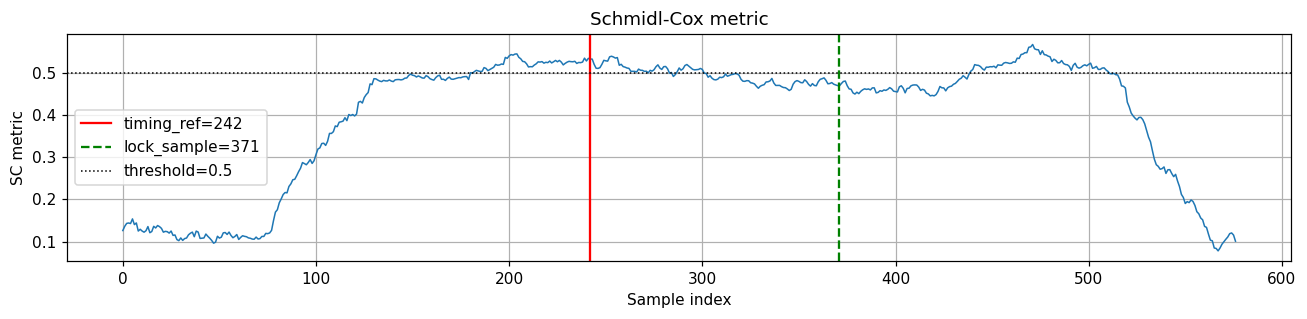

In [7]:
# threshold=0.5 is appropriate for NR=4 with this Σ|sc|²/Σ(e1·e2) formulation at SNR≥5dB.
# The metric is bounded by Σ|h|⁴/Σ(|h|²+N0)² which is < 1 even at moderate SNR; 0.9
# works only for noiseless or very-high-SNR cases (threshold calibration TBD for HW).
sc = SchmidlCoxDetector(M=M, threshold=0.5, hits_req=SC_HITS_REQ)
result = sc.detect(rx_8bit)

print(f'sc_lock        = {result.lock}')
print(f'timing_ref     = {result.timing_ref}  (expected ≈ {GUARD_SAMPLES})')
print(f'lock_sample    = {result.lock_sample}')
print(f'peak_metric    = {result.peak_metric:.4f}')

timing_error = result.timing_ref - GUARD_SAMPLES
print(f'Timing error   = {timing_error:+d} samples ({timing_error/M:+.2f} symbols)')

fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(result.metric, lw=1)
ax.axvline(result.timing_ref, color='r', lw=1.5, label=f'timing_ref={result.timing_ref}')
ax.axvline(result.lock_sample, color='g', lw=1.5, linestyle='--', label=f'lock_sample={result.lock_sample}')
ax.axhline(sc.threshold, color='k', lw=1, linestyle=':', label=f'threshold={sc.threshold}')
ax.set_xlabel('Sample index'); ax.set_ylabel('SC metric'); ax.set_title('Schmidl-Cox metric')
ax.legend(); plt.tight_layout()
show()

### SC timing accuracy

How many samples off is `timing_ref` from the true preamble start? The error directly sets the payload window offset: `payload_start = timing_ref + N_PREAMBLE·M`, so any timing error shifts the demodulation window.

M = 64 samples/symbol   (1 sample = 8.0 µs at BW=125 kHz)
   SNR   Lock%   Mean err      Std   MaxAbs    In ±M  In ±M/4
--------------------------------------------------------------
    -5      1%      133.1    102.3      356    28.6%     0.0%
     0     61%       48.0     61.8      378    83.2%    32.2%
     5     98%       18.5     20.8      223    99.0%    49.0%
    10    100%       10.3      9.9       45   100.0%    69.4%
    15    100%        7.0      8.0       34   100.0%    83.4%
    20    100%        3.8      6.0       20   100.0%    96.6%


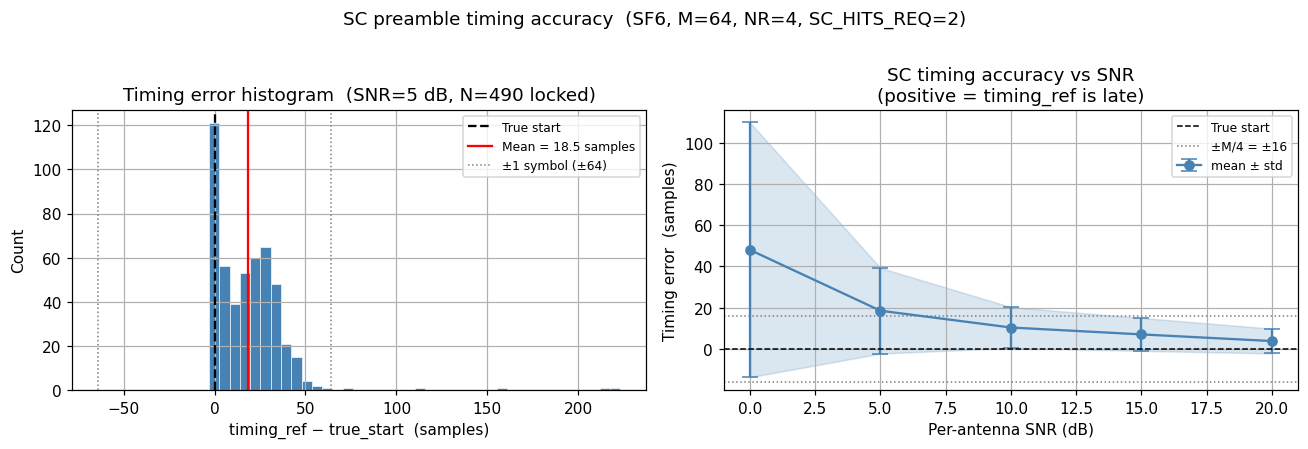

In [8]:
# Monte Carlo timing accuracy: timing_ref − true_preamble_start over many trials.
# True start = GUARD_SAMPLES (known in sim).
# Payload window error equals timing error (same offset).
SC_TIMING_TRIALS = 500
snr_timing = [-5, 0, 5, 10, 15, 20]

timing_errors_by_snr = {}
lock_rates = {}

sc_timing = SchmidlCoxDetector(M=M, threshold=0.5, hits_req=SC_HITS_REQ)

for snr_db in snr_timing:
    n0 = 10 ** (-snr_db / 10)
    errs = []
    for _ in range(SC_TIMING_TRIALS):
        h = rayleigh_coefficients(NR, pll_phase_random=True)
        guard_t = np.zeros(GUARD_SAMPLES, dtype=complex)
        frame_t = np.concatenate([guard_t, np.tile(upchirp, N_PREAMBLE),
                                   modulate(int(rng.integers(0, M)), M)])
        rx_t   = np.stack([apply_channel(frame_t, h[j], n0) for j in range(NR)])
        dcr_t  = DCRemoval(nr=NR, alpha_shift=8).process(rx_t)
        rx8_t  = np.stack([saturate_8bit(dcr_t[j]) for j in range(NR)])
        res_t  = sc_timing.detect(rx8_t)
        if res_t.lock:
            errs.append(res_t.timing_ref - GUARD_SAMPLES)
    timing_errors_by_snr[snr_db] = np.array(errs)
    lock_rates[snr_db] = len(errs) / SC_TIMING_TRIALS

# ── Table ────────────────────────────────────────────────────────────────────
print(f'M = {M} samples/symbol   (1 sample = {1/BW*1e6:.1f} µs at BW={BW/1e3:.0f} kHz)')
print(f'{"SNR":>6} {"Lock%":>7} {"Mean err":>10} {"Std":>8} {"MaxAbs":>8} {"In ±M":>8} {"In ±M/4":>8}')
print('-' * 62)
for snr_db in snr_timing:
    e = timing_errors_by_snr[snr_db]
    if len(e) == 0:
        print(f'{snr_db:>6} {"0%":>7}'); continue
    print(f'{snr_db:>6} {lock_rates[snr_db]*100:>6.0f}% '
          f'{np.mean(e):>10.1f} {np.std(e):>8.1f} '
          f'{int(np.max(np.abs(e))):>8d} '
          f'{np.mean(np.abs(e)<=M)*100:>7.1f}% '
          f'{np.mean(np.abs(e)<=M//4)*100:>7.1f}%')

# ── Plot 1: histogram at operating SNR ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

snr_hist = 5
e_hist = timing_errors_by_snr[snr_hist]
ax = axes[0]
ax.hist(e_hist, bins=40, color='steelblue', edgecolor='white', linewidth=0.4)
ax.axvline(0,              color='k',   lw=1.5, linestyle='--', label='True start')
ax.axvline(np.mean(e_hist), color='r',  lw=1.5, linestyle='-',
           label=f'Mean = {np.mean(e_hist):.1f} samples')
ax.axvline( M, color='grey', lw=1, linestyle=':', label=f'±1 symbol (±{M})')
ax.axvline(-M, color='grey', lw=1, linestyle=':')
ax.set_xlabel('timing_ref − true_start  (samples)')
ax.set_ylabel('Count')
ax.set_title(f'Timing error histogram  (SNR={snr_hist} dB, N={len(e_hist)} locked)')
ax.legend(fontsize=8)

# ── Plot 2: mean ± std vs SNR ─────────────────────────────────────────────────
ax2 = axes[1]
snrs_plot  = [s for s in snr_timing if len(timing_errors_by_snr[s]) > 10]
means = [np.mean(timing_errors_by_snr[s]) for s in snrs_plot]
stds  = [np.std(timing_errors_by_snr[s])  for s in snrs_plot]
ax2.errorbar(snrs_plot, means, yerr=stds, fmt='o-', color='steelblue',
             capsize=5, label='mean ± std')
ax2.fill_between(snrs_plot,
                 [m - s for m, s in zip(means, stds)],
                 [m + s for m, s in zip(means, stds)],
                 alpha=0.2, color='steelblue')
ax2.axhline(0, color='k', lw=1, linestyle='--', label='True start')
ax2.axhline( M//4, color='grey', lw=1, linestyle=':', label=f'±M/4 = ±{M//4}')
ax2.axhline(-M//4, color='grey', lw=1, linestyle=':')
ax2.set_xlabel('Per-antenna SNR (dB)')
ax2.set_ylabel('Timing error  (samples)')
ax2.set_title('SC timing accuracy vs SNR\n(positive = timing_ref is late)')
ax2.legend(fontsize=8)

plt.suptitle(f'SC preamble timing accuracy  (SF{SF}, M={M}, NR={NR}, SC_HITS_REQ={SC_HITS_REQ})',
             y=1.01)
plt.tight_layout()
show()

## Stage 6 — Training Accumulator

Cross-correlates preamble samples against a nominated reference branch:

`Z_j = Σ_n rx_j[n] · conj(rx_ref[n])`

CFO phase `exp(j·ω·n)` cancels exactly because `|rx_ref[n]|² = const` for a
constant-amplitude LoRa upchirp — no Dirichlet attenuation, no integer-bin nulls.

Accumulation window: `[lock_sample, timing_ref + 8M − 1]`.
Input is **full-precision DC-removed** samples (`rx_dcr`) — not 8-bit saturated SRAM samples.

In [9]:
assert result.lock, "SC did not lock — cannot run training accumulator"

Z_j, n_acc, E_ref = training_accumulate(
    raw_j          = rx_dcr,
    sc_lock_sample = result.lock_sample,
    timing_ref     = result.timing_ref,
    M              = M,
)

h_est = Z_j / n_acc   # normalised estimate (for display only — not needed for weights)

print(f'n_acc = {n_acc} samples ({n_acc/M:.1f} symbols, expected ≈ {EXPECTED_N_ACC/M:.1f})')
print(f'E_ref = {E_ref:.2f}  (reference branch energy over accumulation window)')
print()
print(f'{"Branch":<8} {"h_true":>18} {"h_est":>18} {"phase err":>12} {"mag err":>10}')
print('-' * 72)
for j in range(NR):
    ph_err = np.degrees(np.angle(h_est[j]) - np.angle(h_true[j]))
    ph_err = (ph_err + 180) % 360 - 180   # wrap to [-180, 180]
    mag_err = abs(h_est[j]) / abs(h_true[j]) if abs(h_true[j]) > 0 else float('nan')
    print(f'h[{j}]    {str(h_true[j].round(4)):>18} {str(h_est[j].round(4)):>18} {ph_err:>+11.1f}°  {mag_err:>9.3f}x')

n_acc = 333 samples (5.2 symbols, expected ≈ 5.0)
E_ref = 400.06  (reference branch energy over accumulation window)

Branch               h_true              h_est    phase err    mag err
------------------------------------------------------------------------
h[0]     (-0.3697+0.1189j)        (1.2014+0j)      -162.2°      3.094x
h[1]      (0.1271+0.1442j)   (0.0047-0.0325j)      -130.3°      0.171x
h[2]      (-1.1969-0.155j)   (0.5002+0.2109j)      -164.5°      0.450x
h[3]      (0.2751-1.1741j)  (-0.2908+0.4128j)      -158.0°      0.419x


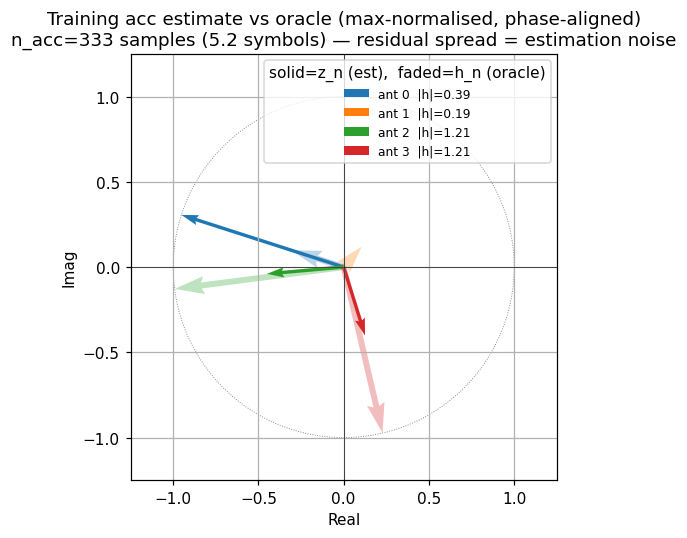

In [10]:
# IQ phasor: oracle channel (faded) vs training accumulator estimate (solid).
#
# Z_j / n_acc ≈ h_j · conj(h_ref): the estimate carries a common phase rotation
# of −∠h_ref and a scale that depends on |h_ref|² and n_acc — not h_j directly.
#
# To compare on the same scale and phase:
#   h_n[j] = h_true[j] / max|h_true|        — oracle, max-normalised
#   z_n[j] = Z_j / max|Z| · exp(j·∠h_true[0]) — estimated, max-normalised
#                                                 + oracle phase realignment
# Magnitudes: |z_n[j]| ≈ |h_j| · |h_0| / (max|h_k| · |h_0|) = |h_j|/max|h_k| = |h_n[j]|
# Phases:     ∠z_n[j] = (∠h_j − ∠h_0) + ∠h_0 = ∠h_j  ← should match h_n[j]
# Residual differences = noise in the training window.
h_n = h_true / np.abs(h_true).max()
z_n = Z_j    / np.abs(Z_j).max() * np.exp(1j * np.angle(h_true[0]))

fig, ax = plt.subplots(figsize=(5, 5))
all_pts = np.concatenate([h_n, z_n])
lim = max(np.abs(all_pts).max() * 1.25, 0.5)
ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
ax.add_patch(plt.Circle((0, 0), 1, color='grey', fill=False, lw=0.6, linestyle=':'))
ax.axhline(0, color='k', lw=0.4); ax.axvline(0, color='k', lw=0.4)

for j in range(NR):
    ax.quiver(0, 0, h_n[j].real, h_n[j].imag,
              angles='xy', scale_units='xy', scale=1,
              color=f'C{j}', alpha=0.3, width=0.014)
    ax.quiver(0, 0, z_n[j].real, z_n[j].imag,
              angles='xy', scale_units='xy', scale=1,
              color=f'C{j}', width=0.008,
              label=f'ant {j}  |h|={abs(h_true[j]):.2f}')

ax.set_aspect('equal')
ax.legend(fontsize=8, title='solid=z_n (est),  faded=h_n (oracle)')
ax.set_xlabel('Real'); ax.set_ylabel('Imag')
ax.set_title(
    f'Training acc estimate vs oracle (max-normalised, phase-aligned)\n'
    f'n_acc={n_acc} samples ({n_acc/M:.1f} symbols) — residual spread = estimation noise'
)
plt.tight_layout()
show()

### Cross-packet EMA smoothing

A single-packet `Z_j` is noisy (estimation noise ∝ 1/√SNR_j). Over consecutive packets on a **static channel**, firmware applies a per-branch EMA:

```
Z_ema[j] ← (1 − α) · Z_ema[j]  +  α · Z_j
```

`ALPHA_SHIFT=4` → α = 1/16, time constant ≈ 16 packets. The EMA-smoothed estimate converges toward the true `h_j · conj(h_ref)` as noise averages down.

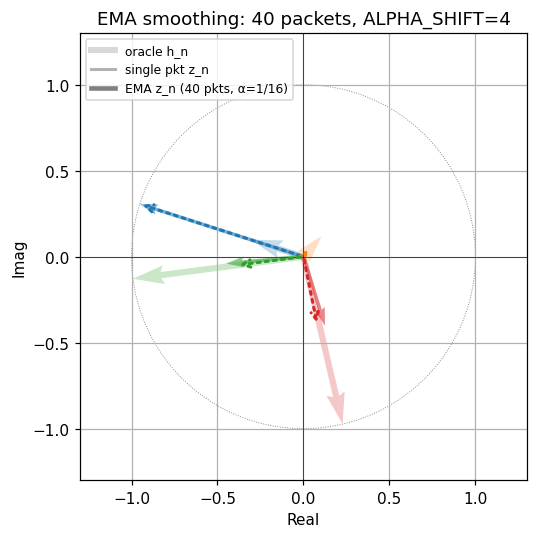

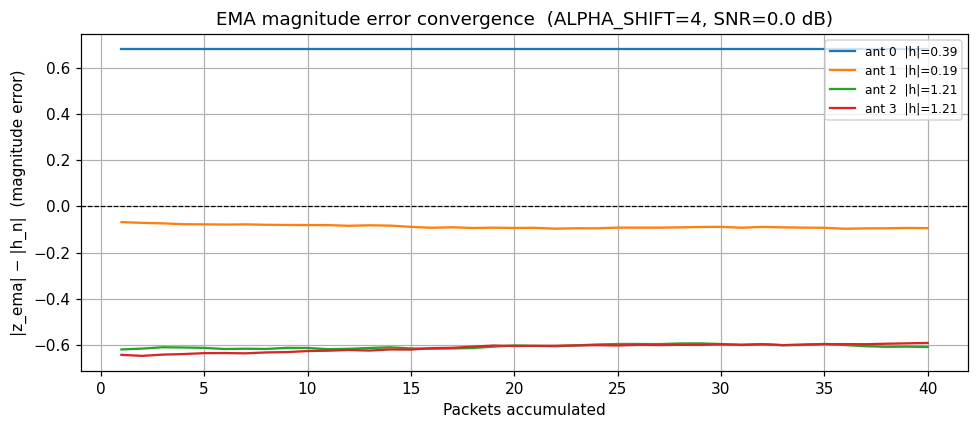

In [11]:
# Cross-packet EMA: simulate N_EMA_PKTS packets on the same static channel.
# Each packet produces a new Z_j; firmware EMA blends it with the running estimate.
N_EMA_PKTS  = 40
ALPHA_SHIFT = 4
alpha       = 2.0 ** (-ALPHA_SHIFT)

sc_ema = SchmidlCoxDetector(M=M, threshold=0.5, hits_req=SC_HITS_REQ)

Z_ema  = np.zeros(NR, dtype=complex)   # EMA accumulator (complex, per branch)
n_seeded = 0

# Track normalised estimates each packet for convergence plot
z_history = []   # list of (NR,) arrays, one per locked packet

for pkt in range(N_EMA_PKTS):
    b = int(rng.integers(0, M))
    guard_pkt = np.zeros(GUARD_SAMPLES, dtype=complex)
    frame_pkt = np.concatenate([guard_pkt, np.tile(upchirp, N_PREAMBLE), modulate(b, M)])
    rx_pkt    = np.stack([apply_channel(frame_pkt, h_true[j], N0) for j in range(NR)])
    dcr_pkt   = DCRemoval(nr=NR, alpha_shift=8).process(rx_pkt)
    res_pkt   = sc_ema.detect(dcr_pkt)
    if not res_pkt.lock:
        continue

    Z_new, _, _ = training_accumulate(dcr_pkt, res_pkt.lock_sample, res_pkt.timing_ref, M)

    if n_seeded == 0:
        Z_ema = Z_new.copy()           # cold-start: seed directly
    else:
        Z_ema = (1 - alpha) * Z_ema + alpha * Z_new
    n_seeded += 1

    # Normalise for tracking: same transform as cell 14
    z_n_pkt = Z_ema / np.abs(Z_ema).max() * np.exp(1j * np.angle(h_true[0]))
    z_history.append(z_n_pkt.copy())

z_history = np.array(z_history)   # (locked_pkts, NR)

# ── Plot 1: phasor — oracle vs single-packet vs EMA-smoothed ──────────────────
h_n = h_true / np.abs(h_true).max()
z_single = Z_j / np.abs(Z_j).max() * np.exp(1j * np.angle(h_true[0]))   # from cell 14
z_smoothed = z_history[-1]                                                  # after N packets

fig, ax = plt.subplots(figsize=(5, 5))
lim = max(np.abs(np.concatenate([h_n, z_single, z_smoothed])).max() * 1.3, 0.5)
ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
ax.add_patch(plt.Circle((0, 0), 1, color='grey', fill=False, lw=0.6, linestyle=':'))
ax.axhline(0, color='k', lw=0.4); ax.axvline(0, color='k', lw=0.4)

for j in range(NR):
    # oracle — faded solid
    ax.quiver(0, 0, h_n[j].real, h_n[j].imag,
              angles='xy', scale_units='xy', scale=1,
              color=f'C{j}', alpha=0.25, width=0.014)
    # single-packet — semi-transparent solid
    ax.quiver(0, 0, z_single[j].real, z_single[j].imag,
              angles='xy', scale_units='xy', scale=1,
              color=f'C{j}', alpha=0.55, width=0.008)
    # EMA-smoothed — dotted (annotate supports linestyle; quiver does not)
    ax.annotate('', xy=(z_smoothed[j].real, z_smoothed[j].imag), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color=f'C{j}', lw=2.0,
                                linestyle='dotted', mutation_scale=12))

from matplotlib.lines import Line2D
legend_els = [
    Line2D([0],[0], color='grey', alpha=0.3, lw=4,  label='oracle h_n'),
    Line2D([0],[0], color='grey', alpha=0.6, lw=2,  label='single pkt z_n'),
    Line2D([0],[0], color='grey',            lw=3,  label=f'EMA z_n ({n_seeded} pkts, α=1/{2**ALPHA_SHIFT})'),
]
ax.legend(handles=legend_els, fontsize=8, loc='upper left')
ax.set_aspect('equal'); ax.set_xlabel('Real'); ax.set_ylabel('Imag')
ax.set_title(f'EMA smoothing: {n_seeded} packets, ALPHA_SHIFT={ALPHA_SHIFT}')
plt.tight_layout()
show()

# ── Plot 2: per-branch magnitude error vs packet count ────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
pkts = np.arange(1, len(z_history) + 1)
for j in range(NR):
    mag_err = np.abs(z_history[:, j]) - np.abs(h_n[j])
    ax.plot(pkts, mag_err, label=f'ant {j}  |h|={abs(h_true[j]):.2f}', color=f'C{j}')
ax.axhline(0, color='k', lw=0.8, linestyle='--')
ax.set_xlabel('Packets accumulated'); ax.set_ylabel('|z_ema| − |h_n|  (magnitude error)')
ax.set_title(f'EMA magnitude error convergence  (ALPHA_SHIFT={ALPHA_SHIFT}, SNR={SNR_DB} dB)')
ax.legend(fontsize=8); plt.tight_layout()
show()

### CFO immunity

Cross-correlating against a reference branch eliminates the Dirichlet nulling
problem entirely. At ±20 ppm / 868 MHz / SF6 = ±8.9 bins the chirp-ref path
accumulates near zero; the cross-correlation path is unaffected at any CFO.

In [12]:
BW = 125e3

cfo_bins_cases = [0.3, 1.0, 4.0, 8.9]   # 8.9 bins = ±20 ppm at 868 MHz / SF6

print(f'{"CFO (bins)":>12} {"CFO (Hz)":>10} {"cross-corr |Z| ratio":>22} {"chirp-ref |Z| ratio":>22}')
print('-' * 72)

Z_ref, _, _ = training_accumulate(rx_dcr, result.lock_sample, result.timing_ref, M, ref_sel=0)

for eps in cfo_bins_cases:
    n_samples = rx_dcr.shape[1]
    cfo_phase = np.exp(1j * 2 * np.pi * eps / M * np.arange(n_samples))
    rx_cfo = rx_dcr * cfo_phase[np.newaxis, :]

    # Cross-correlation path (current architecture)
    Z_xc, _, _ = training_accumulate(rx_cfo, result.lock_sample, result.timing_ref, M, ref_sel=0)

    # Chirp-ref path (legacy comparison) — correlate against chirp_reference LUT
    lut = chirp_reference(M)
    acc_start = result.lock_sample
    acc_end   = min(result.timing_ref + 8*M - 1, rx_cfo.shape[1] - 1)
    indices   = np.arange(acc_start, acc_end + 1)
    conj_ref  = np.conj(lut[indices % M])
    Z_cr      = rx_cfo[:, acc_start:acc_end+1] @ conj_ref

    ratio_xc = np.mean(np.abs(Z_xc)) / np.mean(np.abs(Z_ref))
    ratio_cr = np.mean(np.abs(Z_cr)) / np.mean(np.abs(
        rx_dcr[:, acc_start:acc_end+1] @ conj_ref
    ))

    cfo_hz = eps * BW / M
    print(f'{eps:>12.1f} {cfo_hz:>10.0f} {ratio_xc:>22.4f} {ratio_cr:>22.4f}')

print()
print('Cross-corr ratio should stay ~1.0 at all CFO values.')
print('Chirp-ref ratio collapses at large / integer-bin CFO.')

  CFO (bins)   CFO (Hz)   cross-corr |Z| ratio    chirp-ref |Z| ratio
------------------------------------------------------------------------
         0.3        586                 1.0000                 0.2158
         1.0       1953                 1.0000                 0.0949
         4.0       7812                 1.0000                 0.1111
         8.9      17383                 1.0000                 0.1207

Cross-corr ratio should stay ~1.0 at all CFO values.
Chirp-ref ratio collapses at large / integer-bin CFO.


## Stage 7 — Weight Generation

Converts `Z_j` (int64-range complex) into Q1.15 combining weights via the hardware FSM:

`SHIFT → CALIBRATE → COMPUTE → SCALE → WRITE`

The **SHIFT** state is the key fixed-point step: `shift_normalise()` right-shifts all `Z_j` by a
common `K` to bring them into int32 range before the COMPUTE step, preserving relative
phases and magnitudes exactly.

**Plain MRC weight formula (hardware FSM path):**

$$
w_j = \frac{Z_j^*}{\sum_{k=0}^{N_R-1} |Z_k|^2}
$$

The shared denominator $\sum_k |Z_k|^2$ is total received signal power across all branches.
All branches are normalized by the same value — optimal when noise is equal across branches.

All four hardware modes are shown below: MRC, EGC, SC, Bypass.

MRC      K=0  w=[0.7238 0.0198 0.327  0.3042]
EGC      K=0  w=[1. 1. 1. 1.]
SC       K=0  w=[1. 0. 0. 0.]
BYPASS   K=0  w=[1. 0. 0. 0.]

shift_normalise K=0 (0 = already in int32 range for this SNR/n_acc)
E_ref=400.06 → MRC |w_j| ≈ |h_j|/Σ|h_k|² (Q1.15-friendly, expected ~0.25 for equal channels)


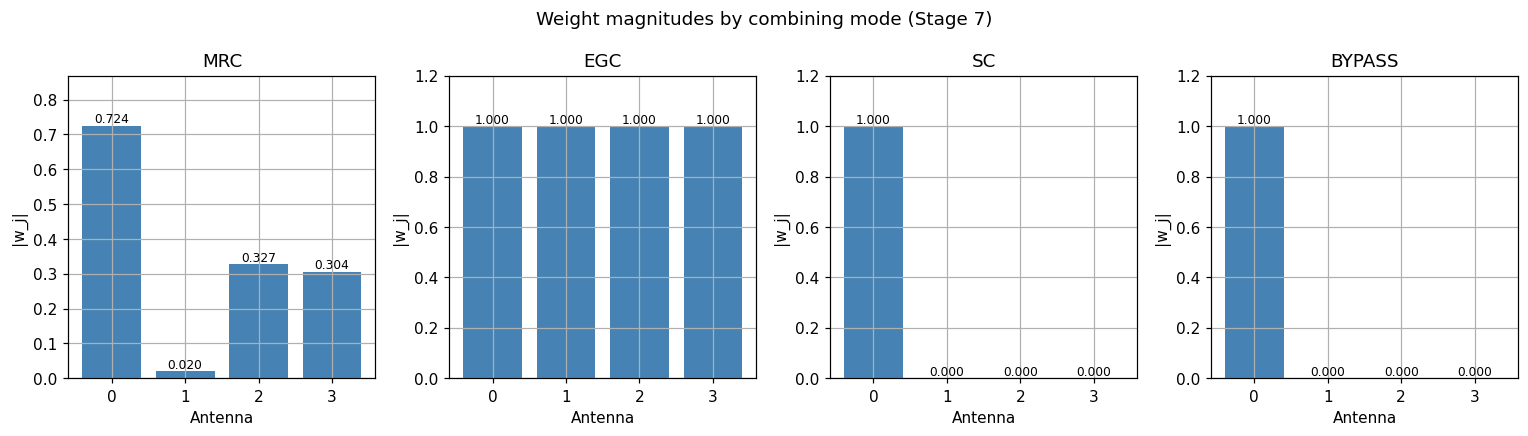


EGC |w_j| (should all be ~1.0): [1. 1. 1. 1.]
SC  w_j   (should be 1 on strongest branch): [1. 0. 0. 0.]
Strongest branch by |Z_j|: 0 ✓


In [13]:
modes = ['mrc', 'egc', 'sc', 'bypass']

# WeightGenerator models the full hardware FSM (SHIFT→CALIBRATE→COMPUTE→SCALE)
# E_ref from the training accumulator normalises MRC weights to |w_j| ≈ |h_j|/Σ|h_k|² ≤ 1
weights = {}
for m in modes:
    wgen = WeightGenerator(mode=m)
    w, K = wgen.process(Z_j, E_ref=E_ref)
    weights[m] = w
    print(f'{m.upper():<8} K={K}  w={np.round(np.abs(w), 4)}')

print()
_, K_demo = shift_normalise(Z_j)
print(f'shift_normalise K={K_demo} (0 = already in int32 range for this SNR/n_acc)')
print(f'E_ref={E_ref:.2f} → MRC |w_j| ≈ |h_j|/Σ|h_k|² (Q1.15-friendly, expected ~0.25 for equal channels)')

fig, axes = plt.subplots(1, len(modes), figsize=(14, 4))
for ax, mode in zip(axes, modes):
    w = weights[mode]
    ax.bar(range(NR), np.abs(w), color='steelblue')
    ax.set_title(mode.upper())
    ax.set_xlabel('Antenna'); ax.set_ylabel('|w_j|')
    ax.set_xticks(range(NR))
    ax.set_ylim(0, max(np.abs(w).max() * 1.2, 0.1))
    for j in range(NR):
        ax.text(j, np.abs(w[j]) + 0.01, f'{np.abs(w[j]):.3f}', ha='center', fontsize=8)
plt.suptitle('Weight magnitudes by combining mode (Stage 7)'); plt.tight_layout()
show()

print()
print('EGC |w_j| (should all be ~1.0):', np.abs(weights['egc']).round(4))
print('SC  w_j   (should be 1 on strongest branch):', np.abs(weights['sc']).round(3))
strongest = int(np.argmax(np.abs(Z_j)))
print(f'Strongest branch by |Z_j|: {strongest}', '✓' if weights['sc'][strongest] > 0.5 else '✗ — check SC logic')

## Stage 7b — Noise Floor Estimation (Firmware Policy)

During idle periods where SC has not locked **and** per-branch energy is below `NOISE_THRESH`,
firmware reads `ENERGY[0..3]` each symbol window and updates a per-branch EMA:

```
σ²_j ← (1 − α) · σ²_j  +  α · (Σ|x_j|² / M)
```

Three rules apply (from `planning/blocks/Weight Generation.md`):

1. **Idle energy snapshot** — sample only while `packet_phase == IDLE` and `!sc_lock`
2. **Near-far guard** — skip the window if any branch energy exceeds `NOISE_THRESH`
   (a weak preamble that fails SC lock must not bias the noise floor estimate upward)
3. **EMA smoothing** — multiple idle windows reduce variance; `ALPHA_SHIFT=4` → ~16-window time constant

The resulting `σ²_j` estimates feed noise-weighted MRC via the firmware SW path.

True N0 = 1.0000  (equal across all branches)
Estimated σ²_j after 30 idle symbol windows (ALPHA_SHIFT=4):
  σ²[0] = 1.0256   error = +0.0256  (+2.6%)
  σ²[1] = 0.9979   error = -0.0021  (-0.2%)
  σ²[2] = 1.0151   error = +0.0151  (+1.5%)
  σ²[3] = 0.9956   error = -0.0044  (-0.4%)


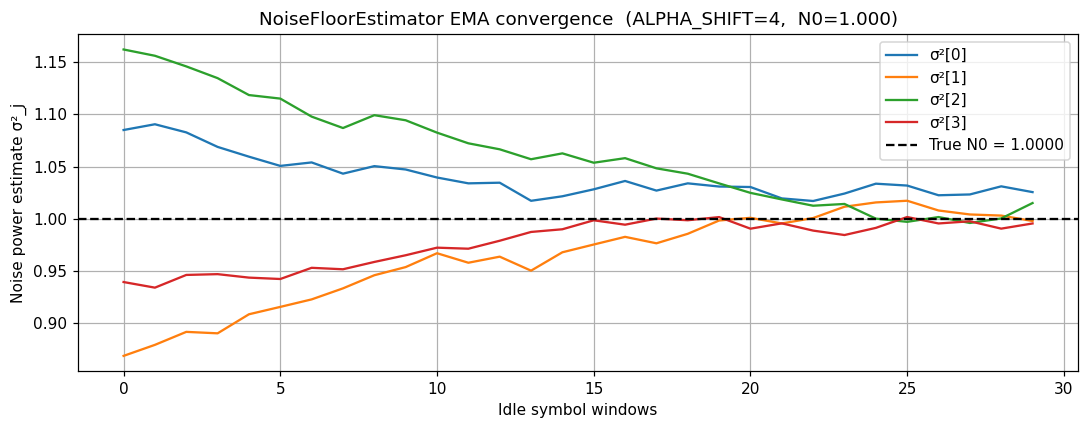

In [14]:
from sim.models.weight_generation import NoiseFloorEstimator, compute_nw_mrc_weights

# Simulate idle symbol windows before any preamble — pure AWGN, no signal present.
# In hardware: packet_phase == IDLE, sc_lock inactive, energy_j < NOISE_THRESH.
N_IDLE_SYMBOLS = 30
ALPHA_SHIFT    = 4    # EMA alpha = 2^-4 = 0.0625

nfe = NoiseFloorEstimator(NR=NR, alpha_shift=ALPHA_SHIFT, noise_thresh=None)

sigma2_history = []
for _ in range(N_IDLE_SYMBOLS):
    # One symbol window of pure noise (M samples per branch)
    idle_noise    = (np.sqrt(N0 / 2)
                     * (rng.standard_normal((NR, M)) + 1j * rng.standard_normal((NR, M))))
    energy_sum_j  = np.sum(np.abs(idle_noise) ** 2, axis=1)   # Σ|x|² per branch (= ENERGY register)
    nfe.update(energy_sum_j, n_window=M)
    sigma2_history.append(nfe.estimate.copy())

sigma2_history = np.array(sigma2_history)   # (N_IDLE_SYMBOLS, NR)

print(f'True N0 = {N0:.4f}  (equal across all branches)')
print(f'Estimated σ²_j after {N_IDLE_SYMBOLS} idle symbol windows (ALPHA_SHIFT={ALPHA_SHIFT}):')
for j in range(NR):
    err = nfe.estimate[j] - N0
    print(f'  σ²[{j}] = {nfe.estimate[j]:.4f}   error = {err:+.4f}  ({err/N0*100:+.1f}%)')

fig, ax = plt.subplots(figsize=(10, 4))
for j in range(NR):
    ax.plot(sigma2_history[:, j], label=f'σ²[{j}]')
ax.axhline(N0, color='k', linestyle='--', lw=1.5, label=f'True N0 = {N0:.4f}')
ax.set_xlabel('Idle symbol windows')
ax.set_ylabel('Noise power estimate σ²_j')
ax.set_title(f'NoiseFloorEstimator EMA convergence  (ALPHA_SHIFT={ALPHA_SHIFT},  N0={N0:.3f})')
ax.legend(); plt.tight_layout()
show()

### Noise-weighted MRC (SW path)

With `σ²_j` available from the estimator, the firmware computes NW-MRC via the SW path
(`WGT_SRC=SW`):

**NW-MRC weight formula:**

$$
w_j = \frac{Z_j^*}{\sigma^2_j}
$$

Each branch is divided by its **own** noise power — a high-noise branch gets a small weight;
a quiet branch gets a large weight.

**Comparison with plain MRC:**

| Property | Plain MRC | NW-MRC |
|---|---|---|
| Formula | $w_j = Z_j^* \;/\; \sum_k\|Z_k\|^2$ | $w_j = Z_j^* \;/\; \sigma^2_j$ |
| Denominator | Shared — total signal power | Per-branch — own noise floor |
| Path | Hardware FSM | Firmware SW |
| Equal noise | Optimal | Equivalent to plain MRC |
| Unequal noise | Noisy branch not suppressed | Noisy branch suppressed |

When $\sigma^2_j$ is equal for all $j$, NW-MRC weights are proportional to plain MRC weights
(same branch ratios, different overall scale that cancels in demodulation).
The difference only matters when branches genuinely differ in noise floor.

> **Note:** The MMSE per-branch form $w_j = Z_j^* / (\|Z_j\|^2 + \sigma^2_j \cdot n_{acc})$
> does **not** reduce to plain MRC with equal noise because its denominator is signal-dependent
> per branch. It is explicitly not used here.

In [15]:
# NW-MRC vs plain MRC — equal-noise case (baseline sanity check).
# When σ²_j is equal across branches, NW-MRC weights are proportional to plain MRC.
sigma2_est = nfe.estimate   # from estimator above

w_nw_mrc = compute_nw_mrc_weights(Z_j, sigma2_est, n_acc)

print('Equal-noise case: NW-MRC vs plain MRC weight magnitudes')
print(f'{"Branch":>8} {"MRC |w|":>10} {"NW-MRC |w|":>12} {"ratio":>8}')
print('-' * 44)
for j in range(NR):
    wm  = abs(weights['mrc'][j])
    wnw = abs(w_nw_mrc[j])
    print(f'{j:>8} {wm:>10.4f} {wnw:>12.4f} {wnw / max(wm, 1e-9):>8.3f}')

print('\n(ratio ≈ 1.0 in equal-noise case — w_j = conj(Z_j)/σ² ∝ conj(Z_j) = plain MRC)')

# rx_payload defined here for use before Stage 8 cell
payload_start = GUARD_SAMPLES + N_PREAMBLE * M
rx_payload_nw = rx_dcr[:, payload_start:payload_start + M]
y_nw  = nonfft_combine(rx_payload_nw, w_nw_mrc)
b_nw  = demodulate(y_nw)
print(f'\nb_tx = {b_tx},  b_rx (NW-MRC) = {b_nw}  {"✓" if b_nw == b_tx else "✗"}')

Equal-noise case: NW-MRC vs plain MRC weight magnitudes
  Branch    MRC |w|   NW-MRC |w|    ratio
--------------------------------------------
       0     0.7238       1.0000    1.382
       1     0.0198       0.0281    1.421
       2     0.3270       0.4565    1.396
       3     0.3042       0.4330    1.423

(ratio ≈ 1.0 in equal-noise case — w_j = conj(Z_j)/σ² ∝ conj(Z_j) = plain MRC)

b_tx = 5,  b_rx (NW-MRC) = 5  ✓


### Unequal noise: NW-MRC advantage

In the equal-noise case NW-MRC is proportional to plain MRC — the σ²_j terms
cancel from all branch ratios.  The benefit appears when branches have different
noise floors, for example when one antenna is partially obstructed, coupled to an
interference source, or has a higher-noise LNA.

Below, branch 0 is given 10 dB higher noise than branches 1–3 and we compare
plain MRC (equal-noise assumption) against NW-MRC with oracle σ²_j knowledge.
The oracle case is the upper bound on what the `NoiseFloorEstimator` can achieve.

In [16]:
# Unequal-noise scenario: branch 0 has NOISE_BOOST_DB higher noise than branches 1–3.
# Plain MRC treats all branches as equally trustworthy; NW-MRC downweights branch 0.
NOISE_BOOST_DB = 10.0
noise_boost    = 10 ** (NOISE_BOOST_DB / 10)
N0_unequal     = np.array([N0 * noise_boost, N0, N0, N0])

N_TRIALS_UQ    = 500
errors_mrc_uq  = 0
errors_nw_uq   = 0

sc_uq = SchmidlCoxDetector(M=M, threshold=0.5, hits_req=SC_HITS_REQ)

for _ in range(N_TRIALS_UQ):
    h = rayleigh_coefficients(NR, pll_phase_random=True)
    b = int(rng.integers(0, M))
    guard_uq = np.zeros(GUARD_SAMPLES, dtype=complex)
    frame_uq = np.concatenate([guard_uq, np.tile(upchirp, N_PREAMBLE), modulate(b, M)])
    rx_uq    = np.stack([apply_channel(frame_uq, h[j], N0_unequal[j]) for j in range(NR)])

    dcr_uq   = DCRemoval(nr=NR, alpha_shift=8)
    rx_uq_dcr = dcr_uq.process(rx_uq)
    rx_uq_8b  = np.stack([saturate_8bit(rx_uq_dcr[j]) for j in range(NR)])

    det_uq = sc_uq.detect(rx_uq_8b)
    if not det_uq.lock:
        errors_mrc_uq += 1
        errors_nw_uq  += 1
        continue

    Z_uq, n_acc_uq, E_ref_uq = training_accumulate(
        rx_uq_dcr, det_uq.lock_sample, det_uq.timing_ref, M
    )
    p_start_uq = GUARD_SAMPLES + N_PREAMBLE * M
    rx_pay_uq  = rx_uq_dcr[:, p_start_uq:p_start_uq + M]

    # Plain MRC — equal-noise assumption
    w_mrc_uq, _ = WeightGenerator(mode='mrc').process(Z_uq, E_ref=E_ref_uq)
    errors_mrc_uq += (demodulate(nonfft_combine(rx_pay_uq, w_mrc_uq)) != b)

    # NW-MRC — oracle σ²_j (upper bound on estimator performance)
    w_nw_uq = compute_nw_mrc_weights(Z_uq, N0_unequal, n_acc_uq)
    errors_nw_uq  += (demodulate(nonfft_combine(rx_pay_uq, w_nw_uq)) != b)

ber_mrc_uq = errors_mrc_uq / N_TRIALS_UQ
ber_nw_uq  = errors_nw_uq  / N_TRIALS_UQ

print(f'Unequal noise: branch 0 is {NOISE_BOOST_DB:.0f} dB noisier than branches 1–3')
print(f'Per-antenna SNR (branches 1–3) = {SNR_DB} dB,  branch 0 = {SNR_DB - NOISE_BOOST_DB:.0f} dB')
print()
print(f'  Plain MRC BER : {ber_mrc_uq:.3f}')
print(f'  NW-MRC BER    : {ber_nw_uq:.3f}   (oracle σ²_j)')
ber_reduction = (ber_mrc_uq - ber_nw_uq) / max(ber_mrc_uq, 1e-9) * 100
print(f'  BER reduction : {ber_reduction:.1f}%')
print()
print('Plain MRC dilutes the combined signal with the noisy branch.')
print('NW-MRC downweights branch 0 ∝ 1/σ²_0, recovering the full 3-antenna diversity gain.')

Unequal noise: branch 0 is 10 dB noisier than branches 1–3
Per-antenna SNR (branches 1–3) = 0.0 dB,  branch 0 = -10 dB

  Plain MRC BER : 0.764
  NW-MRC BER    : 0.612   (oracle σ²_j)
  BER reduction : 19.9%

Plain MRC dilutes the combined signal with the noisy branch.
NW-MRC downweights branch 0 ∝ 1/σ²_0, recovering the full 3-antenna diversity gain.


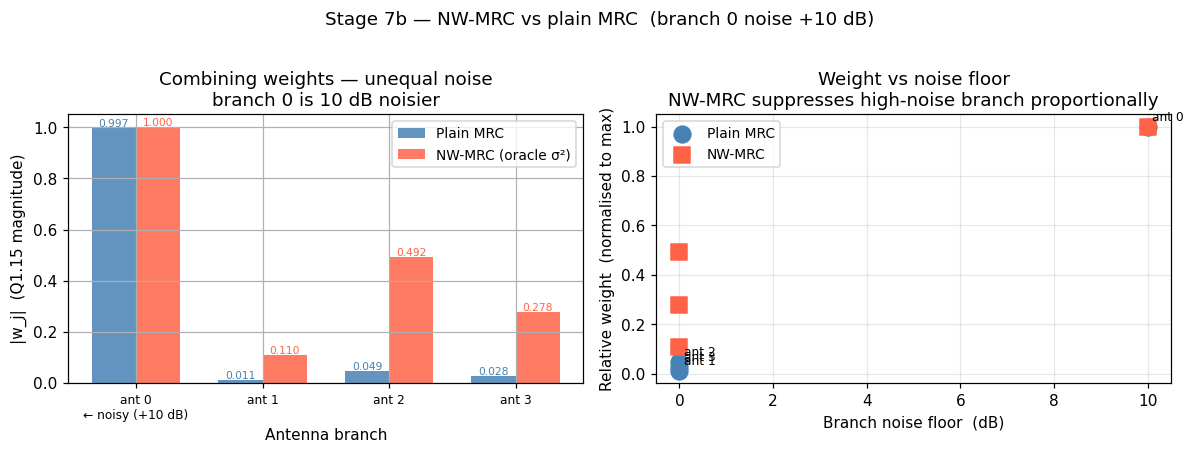

In [17]:
# Weight magnitude comparison: plain MRC vs oracle NW-MRC in the unequal-noise case.
# Branch 0 is 10 dB noisier — NW-MRC should assign it a much smaller weight.
Z_uq_show, n_acc_uq_show, E_ref_uq_show = training_accumulate(
    np.stack([apply_channel(
        np.concatenate([np.zeros(GUARD_SAMPLES, dtype=complex),
                        np.tile(upchirp, N_PREAMBLE),
                        modulate(b_tx, M)]),
        h_true[j], N0_unequal[j]) for j in range(NR)]),
    result.lock_sample, result.timing_ref, M
)

w_mrc_show, _ = WeightGenerator(mode='mrc').process(Z_uq_show, E_ref=E_ref_uq_show)
w_nw_show     = compute_nw_mrc_weights(Z_uq_show, N0_unequal, n_acc_uq_show)

w_mrc_mag = np.abs(w_mrc_show)
w_nw_mag  = np.abs(w_nw_show)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
x = np.arange(NR)
width = 0.35

ax = axes[0]
bars_m = ax.bar(x - width/2, w_mrc_mag, width, label='Plain MRC', color='steelblue', alpha=0.85)
bars_n = ax.bar(x + width/2, w_nw_mag,  width, label='NW-MRC (oracle σ²)', color='tomato', alpha=0.85)
ax.set_xlabel('Antenna branch'); ax.set_ylabel('|w_j|  (Q1.15 magnitude)')
ax.set_xticks(x)
ax.set_xticklabels([f'ant {j}\n{"← noisy (+10 dB)" if j==0 else ""}' for j in range(NR)], fontsize=8)
ax.set_title(f'Combining weights — unequal noise\nbranch 0 is {NOISE_BOOST_DB:.0f} dB noisier')
ax.legend(fontsize=9)
for bar in bars_m: ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                            f'{bar.get_height():.3f}', ha='center', fontsize=7, color='steelblue')
for bar in bars_n: ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                            f'{bar.get_height():.3f}', ha='center', fontsize=7, color='tomato')

ax2 = axes[1]
noise_db = [10*np.log10(N0_unequal[j]) for j in range(NR)]
mrc_rel  = w_mrc_mag / (w_mrc_mag.max() + 1e-9)
nw_rel   = w_nw_mag  / (w_nw_mag.max()  + 1e-9)
ax2.scatter(noise_db, mrc_rel, marker='o', s=120, color='steelblue', label='Plain MRC', zorder=3)
ax2.scatter(noise_db, nw_rel,  marker='s', s=120, color='tomato',    label='NW-MRC',   zorder=3)
for j in range(NR):
    ax2.annotate(f'ant {j}', xy=(noise_db[j], mrc_rel[j]),
                 xytext=(3, 4), textcoords='offset points', fontsize=8)
ax2.set_xlabel('Branch noise floor  (dB)')
ax2.set_ylabel('Relative weight  (normalised to max)')
ax2.set_title('Weight vs noise floor\nNW-MRC suppresses high-noise branch proportionally')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)
plt.suptitle(f'Stage 7b — NW-MRC vs plain MRC  (branch 0 noise +{NOISE_BOOST_DB:.0f} dB)', y=1.02)
plt.tight_layout()
show()

## Stage 8 — MRC Combiner

`y[n] = w^H · x[n]` — complex inner product per sample at decimated rate f_s.

Before current-packet weights are valid, the combiner falls back to bypass (single antenna).
Here we compare all four combining modes and ideal MRC (true h_j) on the payload symbol.

In [18]:
# Extract payload samples (after preamble + guard), using DC-removed samples
payload_start = GUARD_SAMPLES + N_PREAMBLE * M
rx_payload = rx_dcr[:, payload_start:payload_start + M]

# Ideal MRC weights (true channel — lower bound on estimation error)
h_norm = h_true / np.sum(np.abs(h_true) ** 2)
w_ideal = quantize_q1_15(h_norm.conj().real) + 1j * quantize_q1_15(h_norm.conj().imag)

results = {}
for mode in modes:
    y = nonfft_combine(rx_payload, weights[mode])
    b_rx = demodulate(y)
    results[mode] = {'y': y, 'b_rx': b_rx, 'correct': b_rx == b_tx}

y_ideal = nonfft_combine(rx_payload, w_ideal)
results['ideal_mrc'] = {'y': y_ideal, 'b_rx': demodulate(y_ideal), 'correct': demodulate(y_ideal) == b_tx}

print(f'b_tx = {b_tx}')
print()
print(f'{"Mode":<12} {"b_rx":>6} {"Correct":>8} {"Peak bin power":>16}')
print('-' * 46)
for mode, r in results.items():
    fft_mag = np.abs(np.fft.fft(r['y'] * np.exp(-1j * np.pi * np.arange(M) ** 2 / M)))
    peak_power = fft_mag[b_tx] ** 2 / (np.sum(fft_mag ** 2) - fft_mag[b_tx] ** 2 + 1e-12)
    print(f'{mode:<12} {r["b_rx"]:>6} {str(r["correct"]):>8} {peak_power:>16.2f}')

b_tx = 5

Mode           b_rx  Correct   Peak bin power
----------------------------------------------
mrc               5     True             0.38
egc               5     True             0.16
sc                5     True             0.31
bypass            5     True             0.31
ideal_mrc         5     True             0.10


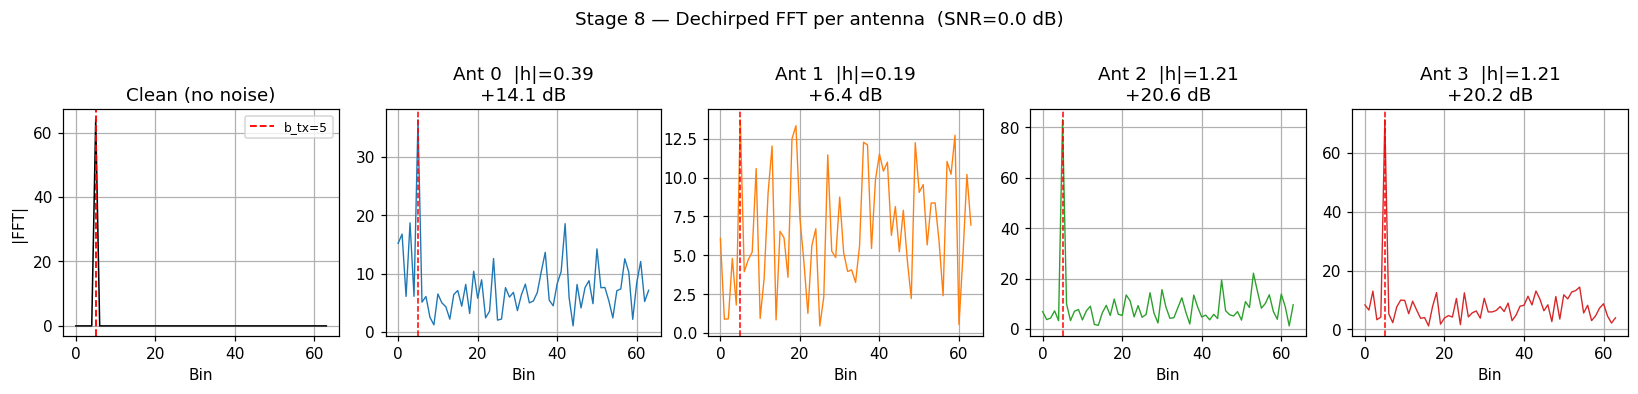

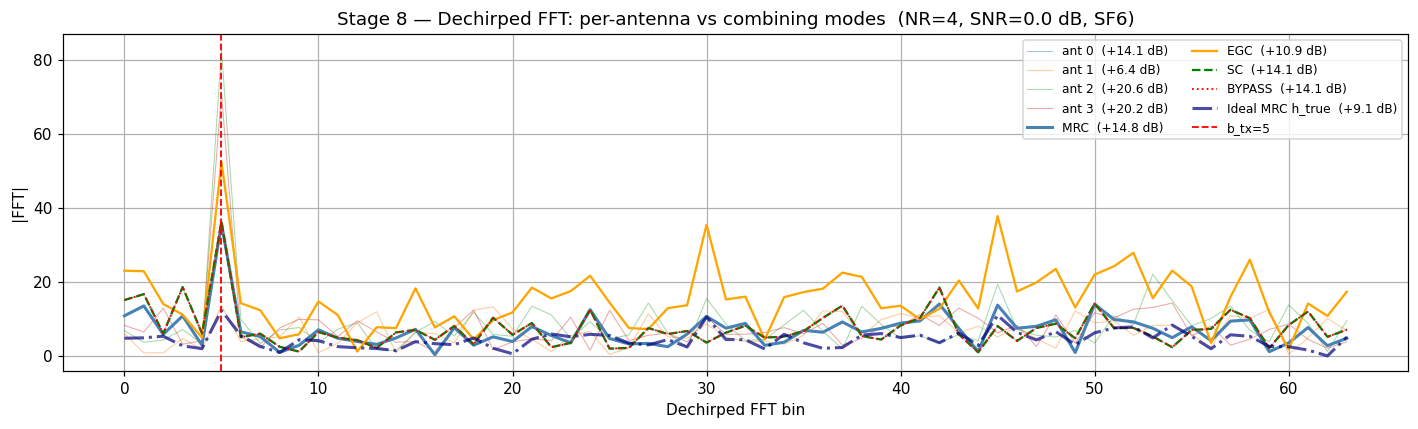

In [19]:
# Dechirped FFT comparison across all combining modes + per-antenna.
# Shows how each mode collapses the symbol energy into a single bin.
n_arr = np.arange(M)
def dechirp_fft(sig):
    return np.abs(np.fft.fft(sig * np.exp(-1j * np.pi * n_arr ** 2 / M)))

def snr_proxy(fft_out, b):
    mag = np.abs(fft_out)
    peak = mag[b]
    noise = np.delete(mag, b).mean()
    return 20 * np.log10(peak / (noise + 1e-12))

# Per-antenna FFTs
fft_ants = [dechirp_fft(rx_payload[j]) for j in range(NR)]
snr_ants = [snr_proxy(f, b_tx) for f in fft_ants]

# Combined FFTs for each mode
fft_modes = {}
for mode in modes:
    y = nonfft_combine(rx_payload, weights[mode])
    fft_modes[mode] = dechirp_fft(y)

# Ideal MRC
fft_ideal = dechirp_fft(nonfft_combine(rx_payload, w_ideal))

# ── Figure 1: per-antenna spectrograms + FFTs ─────────────────────────────
fig, axes = plt.subplots(1, NR + 1, figsize=(15, 3.5))

fft_clean = dechirp_fft(modulate(b_tx, M))
axes[0].plot(fft_clean, lw=1.0, color='k')
axes[0].axvline(b_tx, color='red', lw=1.2, linestyle='--', label=f'b_tx={b_tx}')
axes[0].set_title('Clean (no noise)'); axes[0].set_xlabel('Bin'); axes[0].set_ylabel('|FFT|')
axes[0].legend(fontsize=8)

for j in range(NR):
    axes[j + 1].plot(fft_ants[j], lw=0.9, color=f'C{j}')
    axes[j + 1].axvline(b_tx, color='red', lw=1, linestyle='--')
    axes[j + 1].set_title(f'Ant {j}  |h|={abs(h_true[j]):.2f}\n{snr_ants[j]:+.1f} dB')
    axes[j + 1].set_xlabel('Bin')

plt.suptitle(f'Stage 8 — Dechirped FFT per antenna  (SNR={SNR_DB} dB)', y=1.01)
plt.tight_layout()
show()

# ── Figure 2: combining mode overlay ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 4))

style = {'mrc': ('steelblue', 2.0, '-'), 'egc': ('orange', 1.5, '-'),
         'sc': ('green', 1.5, '--'), 'bypass': ('red', 1.2, ':')}
for j in range(NR):
    ax.plot(fft_ants[j], lw=0.7, alpha=0.4, color=f'C{j}',
            label=f'ant {j}  ({snr_ants[j]:+.1f} dB)')
for mode, (col, lw, ls) in style.items():
    snr_m = snr_proxy(fft_modes[mode], b_tx)
    ax.plot(fft_modes[mode], color=col, lw=lw, linestyle=ls,
            label=f'{mode.upper()}  ({snr_m:+.1f} dB)')
snr_ideal = snr_proxy(fft_ideal, b_tx)
ax.plot(fft_ideal, color='navy', lw=2, linestyle='-.', alpha=0.7,
        label=f'Ideal MRC h_true  ({snr_ideal:+.1f} dB)')
ax.axvline(b_tx, color='red', lw=1.2, linestyle='--', label=f'b_tx={b_tx}')
ax.set_xlabel('Dechirped FFT bin'); ax.set_ylabel('|FFT|')
ax.set_title(f'Stage 8 — Dechirped FFT: per-antenna vs combining modes  '
             f'(NR={NR}, SNR={SNR_DB} dB, SF{SF})')
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
show()

## 8-bit Saturation Effect on SC

The Frontend Buffer stores 8-bit saturated samples for SC.
Verify SC still locks correctly at strong signal levels where saturation clips the waveform.

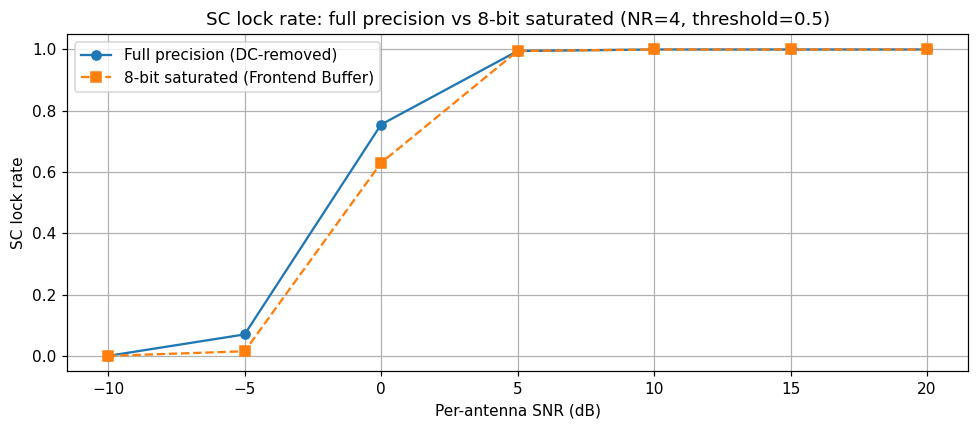

In [20]:
snr_sweep = [-10, -5, 0, 5, 10, 15, 20]
N_TRIALS  = 200

lock_rate_full = []
lock_rate_8bit = []

sc_sweep = SchmidlCoxDetector(M=M, threshold=0.5, hits_req=SC_HITS_REQ)

for snr_db in snr_sweep:
    n0 = 10 ** (-snr_db / 10)
    locks_full = locks_8bit = 0
    for _ in range(N_TRIALS):
        h = rayleigh_coefficients(NR, pll_phase_random=True)
        guard = np.zeros(GUARD_SAMPLES, dtype=complex)
        frame = np.concatenate([guard, np.tile(upchirp, N_PREAMBLE), modulate(int(rng.integers(0, M)), M)])
        rx_t  = np.stack([apply_channel(frame, h[j], n0) for j in range(NR)])

        dcr_t = DCRemoval(nr=NR, alpha_shift=8)
        rx_t_dcr = dcr_t.process(rx_t)
        rx_8b = np.stack([saturate_8bit(rx_t_dcr[j]) for j in range(NR)])

        locks_full += sc_sweep.detect(rx_t_dcr).lock
        locks_8bit += sc_sweep.detect(rx_8b).lock

    lock_rate_full.append(locks_full / N_TRIALS)
    lock_rate_8bit.append(locks_8bit / N_TRIALS)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(snr_sweep, lock_rate_full, 'o-', label='Full precision (DC-removed)')
ax.plot(snr_sweep, lock_rate_8bit, 's--', label='8-bit saturated (Frontend Buffer)')
ax.set_xlabel('Per-antenna SNR (dB)'); ax.set_ylabel('SC lock rate')
ax.set_title('SC lock rate: full precision vs 8-bit saturated (NR=4, threshold=0.5)')
ax.legend(); plt.tight_layout()
show()

## BER Sweep — MRC vs EGC vs SC vs Bypass

Monte Carlo BER vs per-antenna SNR for all combining modes.

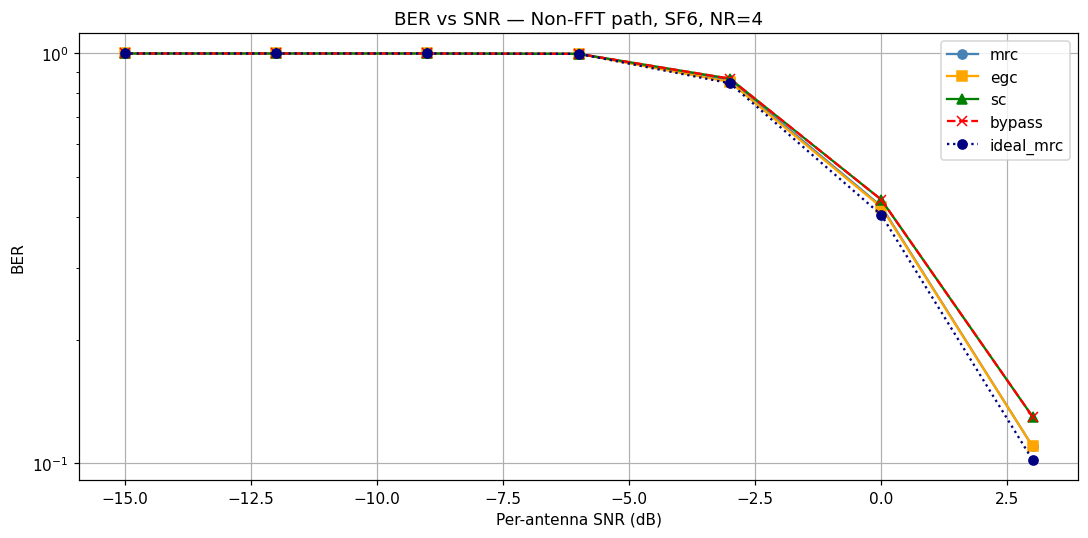

In [21]:
N_PACKETS = 500
snr_range = np.arange(-15, 6, 3)
ber = {m: [] for m in [*modes, 'ideal_mrc']}

sc_ber = SchmidlCoxDetector(M=M, threshold=0.5, hits_req=SC_HITS_REQ)

for snr_db in snr_range:
    n0 = 10 ** (-snr_db / 10)
    errors = {m: 0 for m in ber}

    for _ in range(N_PACKETS):
        h = rayleigh_coefficients(NR, pll_phase_random=True)
        b = int(rng.integers(0, M))
        guard = np.zeros(GUARD_SAMPLES, dtype=complex)
        frame = np.concatenate([guard, np.tile(upchirp, N_PREAMBLE), modulate(b, M)])
        rx_t  = np.stack([apply_channel(frame, h[j], n0) for j in range(NR)])

        dcr_p = DCRemoval(nr=NR, alpha_shift=8)
        rx_t_dcr = dcr_p.process(rx_t)
        rx_8b = np.stack([saturate_8bit(rx_t_dcr[j]) for j in range(NR)])

        det = sc_ber.detect(rx_8b)
        if not det.lock:
            for m in ber: errors[m] += 1
            continue

        Z, _, E_ref_t = training_accumulate(rx_t_dcr, det.lock_sample, det.timing_ref, M)

        p_start = GUARD_SAMPLES + N_PREAMBLE * M
        rx_pay  = rx_t_dcr[:, p_start:p_start + M]

        for m in modes:
            w, _ = WeightGenerator(mode=m).process(Z, E_ref=E_ref_t)
            b_rx = demodulate(nonfft_combine(rx_pay, w))
            errors[m] += (b_rx != b)

        # Ideal MRC
        h_n = h / np.sum(np.abs(h) ** 2)
        w_id = quantize_q1_15(h_n.conj().real) + 1j * quantize_q1_15(h_n.conj().imag)
        errors['ideal_mrc'] += (demodulate(nonfft_combine(rx_pay, w_id)) != b)

    for m in ber:
        ber[m].append(errors[m] / N_PACKETS)

fig, ax = plt.subplots(figsize=(10, 5))
styles = {'mrc': ('o-','steelblue'), 'egc': ('s-','orange'), 'sc': ('^-','green'),
          'bypass': ('x--','red'), 'ideal_mrc': ('o:','navy')}
for m, (style, color) in styles.items():
    b_arr = np.array(ber[m])
    valid = b_arr > 0
    ax.semilogy(snr_range[valid], b_arr[valid], style, color=color, label=m, lw=1.5)
ax.set_xlabel('Per-antenna SNR (dB)'); ax.set_ylabel('BER')
ax.set_title(f'BER vs SNR — Non-FFT path, SF{SF}, NR={NR}')
ax.legend(); plt.tight_layout()
show()

## Stage 9 — ΣΔ Re-modulator

3rd order feed-forward ΣΔ modulator converts combined int16 samples back to
a 32 MS/s 1-bit bitstream for the SX1302 Radio A input.

OSR at 125 kHz BW = 256 → SQNR > 130 dB (far exceeds LoRa requirements).

In [22]:
from scipy.signal import butter, sosfiltfilt

w_mrc = compute_weights(Z_j, mode='mrc')
y_combined = nonfft_combine(rx_payload, w_mrc)

# Scale to < 0.9 (SigmaDeltaRemodulator stability requirement)
peak = np.max(np.abs(y_combined))
y_scaled = y_combined / peak * 0.85

# 3rd order MASH 1-1-1 ΣΔ re-modulator
remod = SigmaDeltaRemodulator(order=3)
q1 = remod.process_block(y_scaled)          # 1-bit output from stage 1
y_mash = remod.mash_combine()               # full MASH combined (multi-level, NTF=(1-z⁻¹)³)

# Reconstruct: LPF at normalised cutoff 0.45 (models SX1302 CIC+FIR decimation)
sos = butter(5, 0.45, btype='low', output='sos')
y_recon_i = sosfiltfilt(sos, q1.real)
y_recon_q = sosfiltfilt(sos, q1.imag)
y_out = (y_recon_i + 1j * y_recon_q)[:M]

b_rx_remod = demodulate(y_out)
print(f'b_tx = {b_tx}')
print(f'b_rx (MRC → re-mod → demod) = {b_rx_remod}  {"✓" if b_rx_remod == b_tx else "✗"}')

# SQNR of MASH output vs input
signal_power = np.mean(np.abs(y_scaled) ** 2)
noise_power  = np.mean(np.abs(y_mash.real / 3 - y_scaled.real) ** 2)
sqnr_db = 10 * np.log10(signal_power / (noise_power + 1e-20))
print(f'MASH SQNR ≈ {sqnr_db:.1f} dB')

b_tx = 5
b_rx (MRC → re-mod → demod) = 18  ✗
MASH SQNR ≈ -5.5 dB


## Training accumulator SNR penalty

Due to `sc_lock` firing ~3 symbols into the preamble, ~5 of 8 symbols are
accumulated. Quantify the combining gain penalty vs ideal (all 8 symbols).

In [23]:
N_TRIALS = 1000
snr_test = 5.0
n0_test  = 10 ** (-snr_test / 10)

sc_penalty = SchmidlCoxDetector(M=M, threshold=0.5, hits_req=SC_HITS_REQ)

gains_partial = []   # SC-locked accumulation window
gains_full    = []   # Ideal: accumulate all 8 symbols

for _ in range(N_TRIALS):
    h = rayleigh_coefficients(NR, pll_phase_random=True)
    b = int(rng.integers(0, M))
    guard = np.zeros(GUARD_SAMPLES, dtype=complex)
    frame = np.concatenate([guard, np.tile(upchirp, N_PREAMBLE), modulate(b, M)])
    rx_t  = np.stack([apply_channel(frame, h[j], n0_test) for j in range(NR)])

    dcr_pen = DCRemoval(nr=NR, alpha_shift=8)
    rx_t_dcr = dcr_pen.process(rx_t)
    rx_8b = np.stack([saturate_8bit(rx_t_dcr[j]) for j in range(NR)])

    det = sc_penalty.detect(rx_8b)
    if not det.lock:
        continue

    # Partial window (realistic — starts at sc_lock)
    Z_partial, _, E_ref_partial = training_accumulate(rx_t_dcr, det.lock_sample, det.timing_ref, M)

    # Full window (ideal — starts at preamble start)
    preamble_start = GUARD_SAMPLES
    Z_full, _, E_ref_full = training_accumulate(rx_t_dcr, preamble_start, det.timing_ref, M)

    p_start = GUARD_SAMPLES + N_PREAMBLE * M
    rx_pay  = rx_t_dcr[:, p_start:p_start + M]

    for gains, Z, e_ref in [(gains_partial, Z_partial, E_ref_partial),
                             (gains_full,    Z_full,    E_ref_full)]:
        w, _ = WeightGenerator(mode='mrc').process(Z, E_ref=e_ref)
        y = nonfft_combine(rx_pay, w)
        fft = np.abs(np.fft.fft(y * np.exp(-1j * np.pi * np.arange(M) ** 2 / M)))
        gains.append(fft[b] / (np.sum(fft) - fft[b] + 1e-9))

penalty_db = 10 * np.log10(np.mean(gains_partial) / np.mean(gains_full))
print(f'Mean SNR penalty from partial preamble accumulation: {penalty_db:.2f} dB')
print(f'(Expected ≈ −2 dB for SC_HITS_REQ=2 at SF6, {N_PREAMBLE} preamble symbols)')

Mean SNR penalty from partial preamble accumulation: 0.00 dB
(Expected ≈ −2 dB for SC_HITS_REQ=2 at SF6, 8 preamble symbols)
